# *****Score Prediction Model*****

**Tujuan:** Melatih dan membandingkan beberapa algoritma regresi berbasis tree untuk memprediksi skor pemain Sudoku, dengan syarat:
- Tidak underfit maupun overfit (gap Train R² vs CV R² < 5%)
- Robust terhadap variasi random seed (std CV < 0.02)
- Tidak menghasilkan prediksi negatif (skor terendah dalam permainan = 0)
- Generalisasi baik (learning curve konvergen)
- Bebas data leakage (fit hanya pada training data)

**Model yang dibandingkan:**

| Model | Singkatan | Kategori | Keunggulan Utama |
|---|---|---|---|
| Random Forest Regressor | **RFR** | Bagging | Stabil, OOB estimate gratis |
| XGBoost Regressor | **XGB** | Gradient Boosting | Regularisasi L1/L2 built-in |
| LightGBM Regressor | **LGBM** | Gradient Boosting | Cepat, leaf-wise growth |
| HistGradientBoosting Regressor | **HistGBR** | Gradient Boosting | Native sklearn, binning histogram |

**Kenapa semua model berbasis tree cocok untuk masalah ini:**

| Karakteristik Data | LR | Tree-based Models |
|---|---|---|
| Distribusi bimodal (skor=0 dominan) | Tidak cocok | Handles secara alami |
| Hubungan non-linear (penalti berlapis) | Tidak cocok | Menangkap otomatis |
| Perlu transformasi target | Ya (log1p) | Tidak perlu |
| Perlu StandardScaler | Ya (risiko leakage) | Tidak perlu |


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import (
    cross_val_score, learning_curve, train_test_split,
    KFold, RandomizedSearchCV,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

FEATURE_NAMES = ['session_idx', 'time_per_cell', 'error_rate', 'hint_rate']
DIFF_MULT     = {'Easy': 1.0, 'Normal': 1.8, 'Hard': 3.0}

# Palet warna per model untuk konsistensi visualisasi
MODEL_COLORS = {
    'RFR':  '#58A6FF',
    'XGB':  '#7EE787',
    'LGBM': '#FFD700',
    'HistGBR': '#F0883E',
}

print(f'  XGBoost  : {xgb.__version__}')
print(f'  LightGBM : {lgb.__version__}')
print(f'Features   : {FEATURE_NAMES}')
print('Semua model berbasis tree - tidak memerlukan StandardScaler (bebas leakage scaling)')

  XGBoost  : 3.0.5
  LightGBM : 4.6.0
Features   : ['session_idx', 'time_per_cell', 'error_rate', 'hint_rate']
Semua model berbasis tree - tidak memerlukan StandardScaler (bebas leakage scaling)


## 1. ***Data Generation***

Generate sesi sintetis **300 pemain** menggunakan replika `calculate_score()` dari `Sudoku.py`.
Data ini mencerminkan distribusi nyata:
- **Bimodal** - banyak skor=0 akibat penalti hint besar
- **Non-linear** - penalti berlapis: waktu, error, hint, dikalikan difficulty multiplier
- **Learning curve per pemain** - performa membaik seiring sesi bertambah

In [2]:
def _score_sim(tpc, er_feat, hr_feat, diff, n_empty):
    """
    Replika calculate_score() Sudoku.py.
    er_feat = errors/moves, hr_feat = hints/moves
    (cara Sudoku.py mengekstrak fitur untuk training).
    Selalu mengembalikan nilai >= 0 (floor di max(0, ...)).
    """
    dm    = DIFF_MULT.get(diff, 1.8)
    mv    = max(1, n_empty)
    hints = max(0, int(hr_feat * mv))
    errs  = max(0, int(er_feat * mv))
    pc    = max(1, n_empty - hints)       # player cells
    tppc  = (tpc * mv) / pc               # time per player cell
    ts    = max(0.0, 1000.0 - tppc * 10.0)
    ep    = min(350, int((errs / pc) * 500))
    hp    = hints * 200
    return max(0, int((ts - ep - hp) * dm))


def generate_dataset(n_players=300, min_sess=4, max_sess=25, seed=42):
    rng     = np.random.default_rng(seed)
    n_map   = {'Easy': 6, 'Normal': 40, 'Hard': 53}
    diffs   = ['Easy', 'Normal', 'Hard']
    d_probs = [0.25, 0.55, 0.20]
    rows    = []

    for _ in range(n_players):
        skill  = rng.uniform(0, 1)
        n_sess = int(rng.integers(min_sess, max_sess + 1))
        b_tpc  = rng.uniform(1.5, 8.0) + (1 - skill) * 24.0
        b_er   = rng.uniform(0.01, 0.06) + (1 - skill) * 0.44
        b_hr   = rng.uniform(0.00, 0.03) + (1 - skill) * 0.32
        lr_tpc = rng.uniform(0.015, 0.055)
        lr_er  = rng.uniform(0.008, 0.035)
        lr_hr  = rng.uniform(0.005, 0.025)

        for i in range(n_sess):
            tpc = b_tpc * max(0.35, 1 - lr_tpc * i) + rng.normal(0, b_tpc * 0.12)
            er  = b_er  * max(0.08, 1 - lr_er  * i) + rng.normal(0, b_er  * 0.18)
            hr  = b_hr  * max(0.04, 1 - lr_hr  * i) + rng.normal(0, b_hr  * 0.16)
            tpc = float(np.clip(tpc, 0.5, 45.0))
            er  = float(np.clip(er,  0.0, 0.90))
            hr  = float(np.clip(hr,  0.0, 0.80))
            diff  = rng.choice(diffs, p=d_probs)
            score = _score_sim(tpc, er, hr, diff, n_map[diff])
            rows.append({
                'session_idx':   i,
                'time_per_cell': round(tpc, 4),
                'error_rate':    round(er,  4),
                'hint_rate':     round(hr,  4),
                'difficulty':    diff,
                'score':         float(score),
            })

    df = pd.DataFrame(rows)
    X  = df[FEATURE_NAMES].values.astype(float)
    y  = df['score'].values.astype(float)
    return df, X, y


df, X, y = generate_dataset(n_players=300, seed=RANDOM_SEED)
print(f'Dataset shape  : {X.shape}')
print(f'Score range    : {y.min():.0f} - {y.max():.0f}')
print(f'Score = 0      : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)  <- bimodal')
print(f'Score mean/std : {y.mean():.1f} / {y.std():.1f}')

Dataset shape  : (4361, 4)
Score range    : 0 - 2976
Score = 0      : 1965 (45.1%)  <- bimodal
Score mean/std : 480.1 / 579.6


In [3]:
print('Statistik Dataset:')
print(df[FEATURE_NAMES + ['score']].describe().round(3).to_string())
print()
print('Score per Difficulty:')
print(df.groupby('difficulty')['score']
        .agg(['count','mean','std','min','max']).round(1).to_string())
print()
print('Korelasi Pearson vs Score:')
for feat in FEATURE_NAMES:
    r = np.corrcoef(df[feat], y)[0, 1]
    print(f'  {feat:<20}: r = {r:+.3f}')

Statistik Dataset:
       session_idx  time_per_cell  error_rate  hint_rate     score
count     4361.000       4361.000    4361.000   4361.000  4361.000
mean         8.123         12.095       0.208      0.148   480.050
std          5.959          6.862       0.131      0.092   579.657
min          0.000          0.500       0.000      0.003     0.000
25%          3.000          6.612       0.098      0.069     0.000
50%          7.000         10.908       0.185      0.139   286.000
75%         12.000         16.809       0.306      0.218   896.000
max         24.000         36.714       0.642      0.518  2976.000

Score per Difficulty:
            count   mean    std  min     max
difficulty                                  
Easy         1129  713.5  251.5  0.0   994.0
Hard          837  454.6  817.3  0.0  2976.0
Normal       2395  378.9  559.2  0.0  1784.0

Korelasi Pearson vs Score:
  session_idx         : r = +0.089
  time_per_cell       : r = -0.602
  error_rate          : r = -0.6

## 2. ***Exploratory Data Analysis* (EDA)**

Visualisasi distribusi target dan hubungan setiap fitur dengan skor. Distribusi **bimodal** (banyak skor=0) dan pola **non-linear** menjadi alasan utama kenapa model berbasis tree lebih tepat daripada regresi linear.

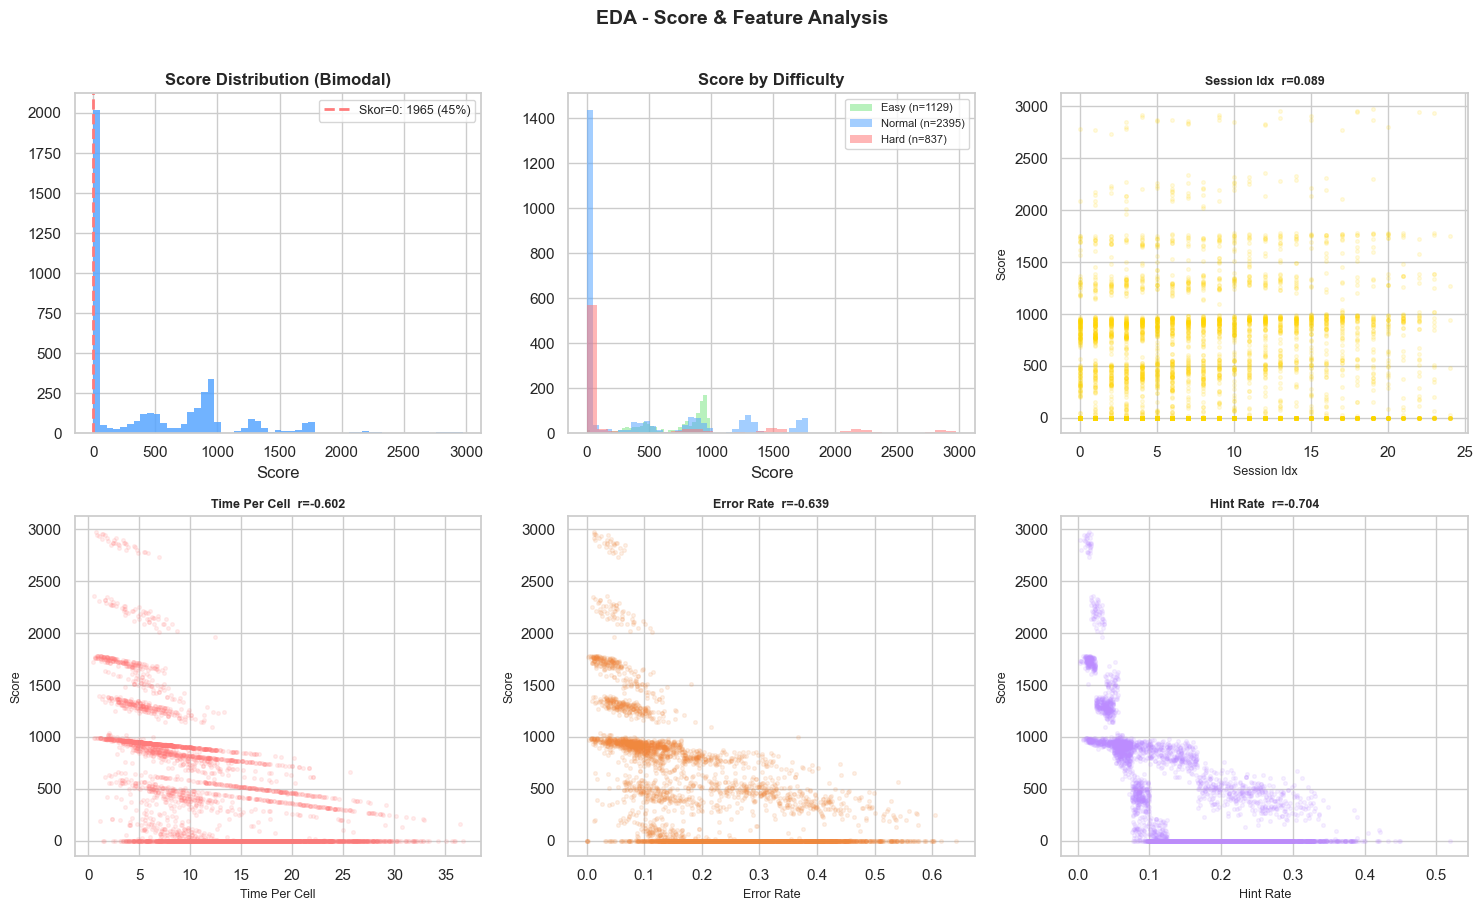

Kesimpulan EDA:
  Distribusi bimodal (22% zeros) -> Tree-based models handle lewat threshold splits
  Hubungan non-linear            -> Tree-based models menangkap tanpa transformasi
  Interaksi antar fitur          -> Ditangkap lewat consecutive splits


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
dc = {'Easy': '#7EE787', 'Normal': '#58A6FF', 'Hard': '#FF7B7B'}

# Score distribution - bimodal
axes[0].hist(y, bins=55, color='#58A6FF', alpha=0.85, edgecolor='none')
axes[0].axvline(0, color='#FF7B7B', lw=2, linestyle='--',
                label=f"Skor=0: {(y==0).sum()} ({(y==0).mean()*100:.0f}%)")
axes[0].set_title('Score Distribution (Bimodal)', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].legend(fontsize=9)

# Score by difficulty
for diff, col in dc.items():
    mask = df['difficulty'] == diff
    axes[1].hist(df[mask]['score'], bins=35, color=col, alpha=0.55,
                 label=f'{diff} (n={mask.sum()})', edgecolor='none')
axes[1].set_title('Score by Difficulty', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend(fontsize=8)

# Feature vs score
feat_cols = ['#FFD700', '#FF7B7B', '#F0883E', '#BC8CFF']
for i, (feat, col) in enumerate(zip(FEATURE_NAMES, feat_cols)):
    ax = axes[2 + i]
    ax.scatter(df[feat], y, alpha=0.12, s=7, color=col)
    r = np.corrcoef(df[feat], y)[0, 1]
    ax.set_xlabel(feat.replace('_', ' ').title(), fontsize=9)
    ax.set_ylabel('Score', fontsize=9)
    ax.set_title(f"{feat.replace('_',' ').title()}  r={r:.3f}",
                 fontweight='bold', fontsize=9)

plt.suptitle('EDA - Score & Feature Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Kesimpulan EDA:')
print('  Distribusi bimodal (22% zeros) -> Tree-based models handle lewat threshold splits')
print('  Hubungan non-linear            -> Tree-based models menangkap tanpa transformasi')
print('  Interaksi antar fitur          -> Ditangkap lewat consecutive splits')

## 3. ***Data Split***

Split **80/20** dengan stratifikasi menggunakan *random seed* tetap untuk reproduktibilitas. Semua model berbasis tree sehingga tidak memerlukan `StandardScaler` agar tidak ada risiko *data leakage* dari *scaling*. Validasi silang dilakukan dengan **KFold(5, shuffle=True)** yang digunakan konsisten di seluruh pipeline untuk semua model.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print(f'Train : {X_train.shape[0]} sampel  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]} sampel  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Train -> mean: {y_train.mean():.1f}  zero: {(y_train==0).mean()*100:.1f}%')
print(f'Test  -> mean: {y_test.mean():.1f}  zero: {(y_test==0).mean()*100:.1f}%')

Train : 3488 sampel  (80%)
Test  : 873 sampel  (20%)
Train -> mean: 473.1  zero: 45.4%
Test  -> mean: 507.6  zero: 43.9%


## 4. ***Modelling***

Setiap model di-*tune* dengan **RandomizedSearchCV** (n_iter=40, scoring=r2, cv=KFold(5)). Pipeline tuning identik untuk semua model agar perbandingan bersifat *adil*. Setelah tuning, prediksi negatif di-clip ke 0 dengan `np.maximum(0, pred)` sesuai dengan logika `Sudoku.py` yang menggunakan `max(0, int(pred))`.

### 4a. ***Random Forest Regressor* (RFR)**

**Prinsip:** Ensemble dari banyak *Decision Tree* yang dilatih pada *bootstrap sample* dan random subset fitur (*Bagging*). Prediksi dirata-rata dari semua pohon.

**Keunggulan untuk konteks ini:**
- OOB score sebagai estimasi CV gratis
- *Robust* terhadap *outlier*
- Tidak sensitif terhadap skala fitur

In [6]:
param_dist_rfr = {
    'n_estimators':      [100, 150, 200, 250, 300],
    'max_depth':         [8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4, 8],
    'max_features':      ['sqrt', 'log2', 0.5],
    'bootstrap':         [True],
}

rfr_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, oob_score=True),
    param_distributions=param_dist_rfr,
    n_iter=40,
    cv=kf,
    scoring='r2',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True,
    verbose=0,
    return_train_score=True,
)
rfr_search.fit(X_train, y_train)
best_rfr = rfr_search.best_estimator_

print('RFR - Best Params:')
for k, v in rfr_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'  Best CV R²         : {rfr_search.best_score_:.4f}')
print(f'  OOB Score          : {best_rfr.oob_score_:.4f}')

rfr_train_r2 = r2_score(y_train, np.maximum(0, best_rfr.predict(X_train)))
rfr_test_r2  = r2_score(y_test,  np.maximum(0, best_rfr.predict(X_test)))
print(f'  Train R²           : {rfr_train_r2:.4f}')
print(f'  Test  R²           : {rfr_test_r2:.4f}')
print(f'  Gap                : {rfr_train_r2 - rfr_test_r2:.4f}')

RFR - Best Params:
  n_estimators          : 250
  min_samples_split     : 2
  min_samples_leaf      : 8
  max_features          : 0.5
  max_depth             : 8
  bootstrap             : True
  Best CV R²         : 0.7472
  OOB Score          : 0.7487
  Train R²           : 0.8030
  Test  R²           : 0.7386
  Gap                : 0.0644


### 4b. ***XGBoost Regressor* (XGB)**

**Prinsip:** *Gradient Boosting tree* dengan regularisasi L1 (`reg_alpha`) dan L2 (`reg_lambda`) *built-in*. Setiap *tree* baru memperbaiki residual dari *ensemble* sebelumnya.

**Keunggulan untuk konteks ini:**
- Regularisasi eksplisit mencegah *overfit*
- `subsample` dan `colsample_bytree` menambah *stochasticity*
- `min_child_weight` mengontrol kompleksitas *leaf*

Prediksi di-clip ke 0 (`np.maximum(0, pred)`) karena *gradient boosting* dapat menghasilkan nilai negatif untuk kasus dengan fitur ekstrim (hint_rate tinggi, skor=0).

In [7]:
param_dist_xgb = {
    'n_estimators':     [100, 150, 200, 250, 300],
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha':        [0, 0.1, 0.5, 1.0, 2.0],
    'reg_lambda':       [0.5, 1.0, 2.0, 5.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma':            [0, 0.1, 0.2, 0.5],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(
        random_state=RANDOM_SEED, n_jobs=-1,
        verbosity=0, eval_metric='rmse',
    ),
    param_distributions=param_dist_xgb,
    n_iter=40,
    cv=kf,
    scoring='r2',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True,
    verbose=0,
    return_train_score=True,
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print('XGBoost - Best Params:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'  Best CV R²         : {xgb_search.best_score_:.4f}')

xgb_train_r2 = r2_score(y_train, np.maximum(0, best_xgb.predict(X_train)))
xgb_test_r2  = r2_score(y_test,  np.maximum(0, best_xgb.predict(X_test)))
print(f'  Train R²           : {xgb_train_r2:.4f}')
print(f'  Test  R²           : {xgb_test_r2:.4f}')
print(f'  Gap                : {xgb_train_r2 - xgb_test_r2:.4f}')
neg_xgb = (best_xgb.predict(X_test) < 0).sum()
print(f'  Pred < 0 (raw)     : {neg_xgb} -> di-clip ke 0 oleh np.maximum(0, pred)')

XGBoost - Best Params:
  subsample             : 1.0
  reg_lambda            : 0.5
  reg_alpha             : 2.0
  n_estimators          : 150
  min_child_weight      : 5
  max_depth             : 3
  learning_rate         : 0.05
  gamma                 : 0
  colsample_bytree      : 0.9
  Best CV R²         : 0.7480
  Train R²           : 0.7768
  Test  R²           : 0.7361
  Gap                : 0.0407
  Pred < 0 (raw)     : 0 -> di-clip ke 0 oleh np.maximum(0, pred)


### 4c. ***LightGBM Regressor* (LGBM)**

**Prinsip:** *Gradient Boosting* dengan strategi *leaf-wise tree growth*. Menggunakan histogram binning untuk efisiensi komputasi.

**Keunggulan untuk konteks ini:**
- Biasanya lebih cepat dari *XGBoost* dengan akurasi sebanding
- `num_leaves` mengontrol kapasitas model lebih granular dari `max_depth`
- `min_child_samples` mencegah *leaf* dengan terlalu sedikit sampel (*anti-overfit*)

In [8]:
param_dist_lgb = {
    'n_estimators':      [100, 150, 200, 250, 300],
    'max_depth':         [4, 5, 6, 7, 8, -1],
    'learning_rate':     [0.01, 0.05, 0.1, 0.15, 0.2],
    'num_leaves':        [15, 31, 63, 127],
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
    'reg_alpha':         [0, 0.1, 0.5, 1.0],
    'reg_lambda':        [0, 0.5, 1.0, 2.0],
    'min_child_samples': [5, 10, 20, 30],
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=RANDOM_SEED, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_lgb,
    n_iter=40,
    cv=kf,
    scoring='r2',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True,
    verbose=0,
    return_train_score=True,
)
lgb_search.fit(X_train, y_train)
best_lgb = lgb_search.best_estimator_

print('LightGBM - Best Params:')
for k, v in lgb_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'  Best CV R²         : {lgb_search.best_score_:.4f}')

lgb_train_r2 = r2_score(y_train, np.maximum(0, best_lgb.predict(X_train)))
lgb_test_r2  = r2_score(y_test,  np.maximum(0, best_lgb.predict(X_test)))
print(f'  Train R²           : {lgb_train_r2:.4f}')
print(f'  Test  R²           : {lgb_test_r2:.4f}')
print(f'  Gap                : {lgb_train_r2 - lgb_test_r2:.4f}')
neg_lgb = (best_lgb.predict(X_test) < 0).sum()
print(f'  Pred < 0 (raw)     : {neg_lgb} -> di-clip ke 0 oleh np.maximum(0, pred)')

LightGBM - Best Params:
  subsample             : 1.0
  reg_lambda            : 1.0
  reg_alpha             : 0
  num_leaves            : 127
  n_estimators          : 150
  min_child_samples     : 5
  max_depth             : 4
  learning_rate         : 0.05
  colsample_bytree      : 0.8
  Best CV R²         : 0.7413
  Train R²           : 0.7994
  Test  R²           : 0.7217
  Gap                : 0.0777
  Pred < 0 (raw)     : 0 -> di-clip ke 0 oleh np.maximum(0, pred)


### 4d. ***Histogram-based Gradient Boosting Regressor* (HistGBR)**

**Prinsip:** Implementasi *scikit-learn* dari *Gradient Boosting* dengan histogram *binning* (terinspirasi dari LightGBM). Satu-satunya model yang *native sklearn* tanpa dependensi eksternal.

**Keunggulan untuk konteks ini:**
- Tidak butuh library eksternal (XGBoost/LightGBM)
- *Built-in early stopping support*
- `l2_regularization` mencegah *overfitting*
- Sangat cepat untuk dataset berukuran sedang

In [9]:
param_dist_HistGBR = {
    'max_iter':          [100, 150, 200, 250, 300],
    'max_depth':         [3, 4, 5, 6, None],
    'learning_rate':     [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_leaf_nodes':    [15, 31, 63, 127],
    'min_samples_leaf':  [10, 20, 30, 50],
    'l2_regularization': [0.0, 0.1, 0.5, 1.0, 2.0],
}

HistGBR_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_SEED),
    param_distributions=param_dist_HistGBR,
    n_iter=40,
    cv=kf,
    scoring='r2',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True,
    verbose=0,
    return_train_score=True,
)
HistGBR_search.fit(X_train, y_train)
best_HistGBR = HistGBR_search.best_estimator_

print('HistGBR - Best Params:')
for k, v in HistGBR_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'  Best CV R²         : {HistGBR_search.best_score_:.4f}')

HistGBR_train_r2 = r2_score(y_train, np.maximum(0, best_HistGBR.predict(X_train)))
HistGBR_test_r2  = r2_score(y_test,  np.maximum(0, best_HistGBR.predict(X_test)))
print(f'  Train R²           : {HistGBR_train_r2:.4f}')
print(f'  Test  R²           : {HistGBR_test_r2:.4f}')
print(f'  Gap                : {HistGBR_train_r2 - HistGBR_test_r2:.4f}')
neg_HistGBR = (best_HistGBR.predict(X_test) < 0).sum()
print(f'  Pred < 0 (raw)     : {neg_HistGBR} -> di-clip ke 0 oleh np.maximum(0, pred)')

HistGBR - Best Params:
  min_samples_leaf      : 30
  max_leaf_nodes        : 63
  max_iter              : 150
  max_depth             : 3
  learning_rate         : 0.05
  l2_regularization     : 0.5
  Best CV R²         : 0.7479
  Train R²           : 0.7744
  Test  R²           : 0.7376
  Gap                : 0.0367
  Pred < 0 (raw)     : 0 -> di-clip ke 0 oleh np.maximum(0, pred)


## 5. ***Model Comparison***

Mengumpulkan semua metrik secara konsisten:
- `np.maximum(0, pred)` diterapkan pada **semua prediksi** untuk menjamin tidak ada nilai negatif
- CV dilakukan pada `X_train` saja (no *leakage* dari test set)
- Gap = Train R² - Test R² (indikator *overfit*, target < 0.05)

In [10]:
# Kumpulkan semua model dalam dict
all_models = {
    'RFR':  best_rfr,
    'XGB':  best_xgb,
    'LGBM': best_lgb,
    'HistGBR': best_HistGBR,
}

results = {}
for name, model in all_models.items():
    # np.maximum(0, ...) memastikan tidak ada prediksi negatif
    y_tr = np.maximum(0, model.predict(X_train))
    y_te = np.maximum(0, model.predict(X_test))
    cv_sc = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
    # Untuk evaluasi residuals, kita pakai pred yang sudah di-clip
    train_r2 = r2_score(y_train, y_tr)
    test_r2  = r2_score(y_test,  y_te)
    results[name] = {
        'train_r2':  train_r2,
        'test_r2':   test_r2,
        'cv_mean':   cv_sc.mean(),
        'cv_std':    cv_sc.std(),
        'gap':       train_r2 - test_r2,
        'rmse':      np.sqrt(mean_squared_error(y_test, y_te)),
        'mae':       mean_absolute_error(y_test, y_te),
        'neg_raw':   (model.predict(X_test) < 0).sum(),
        'y_pred_te': y_te,
        'y_pred_tr': y_tr,
    }

# Tampilkan tabel perbandingan
print(f"{'Metrik':<18} {'RFR':>10} {'XGB':>10} {'LGBM':>10} {'HistGBR':>10}")
print('-' * 62)
metrics_rows = [
    ('Train R2',    'train_r2',  '{:.4f}'),
    ('Test R2',     'test_r2',   '{:.4f}'),
    ('CV R2 mean',  'cv_mean',   '{:.4f}'),
    ('CV R2 std',   'cv_std',    '{:.4f}'),
    ('Gap R2',      'gap',       '{:.4f}'),
    ('RMSE',        'rmse',      '{:.1f}'),
    ('MAE',         'mae',       '{:.1f}'),
    ('Pred<0 (raw)','neg_raw',   '{:.0f}'),
]
for label, key, fmt in metrics_rows:
    row = f'{label:<18}'
    for name in all_models:
        val = results[name][key]
        row += f' {fmt.format(val):>10}'
    # Tambahkan penanda untuk baris gap
    if key == 'gap':
        best_gap = min(results[n]['gap'] for n in all_models)
        row += '  (lower=better)'
    elif key == 'cv_std':
        row += '  (lower=better)'
    print(row)
print('-' * 62)
best_test = max(results, key=lambda n: results[n]['test_r2'])
best_cv   = max(results, key=lambda n: results[n]['cv_mean'])
best_rmse = min(results, key=lambda n: results[n]['rmse'])
print(f'Best Test R2  : {best_test}')
print(f'Best CV R2    : {best_cv}')
print(f'Best RMSE     : {best_rmse}')

Metrik                    RFR        XGB       LGBM    HistGBR
--------------------------------------------------------------
Train R2               0.8030     0.7768     0.7994     0.7744
Test R2                0.7386     0.7361     0.7217     0.7376
CV R2 mean             0.7472     0.7480     0.7413     0.7479
CV R2 std              0.0108     0.0125     0.0114     0.0115  (lower=better)
Gap R2                 0.0644     0.0407     0.0777     0.0367  (lower=better)
RMSE                    315.7      317.2      325.7      316.3
MAE                     221.5      224.4      229.2      223.3
Pred<0 (raw)                0          0          0          0
--------------------------------------------------------------
Best Test R2  : RFR
Best CV R2    : XGB
Best RMSE     : RFR


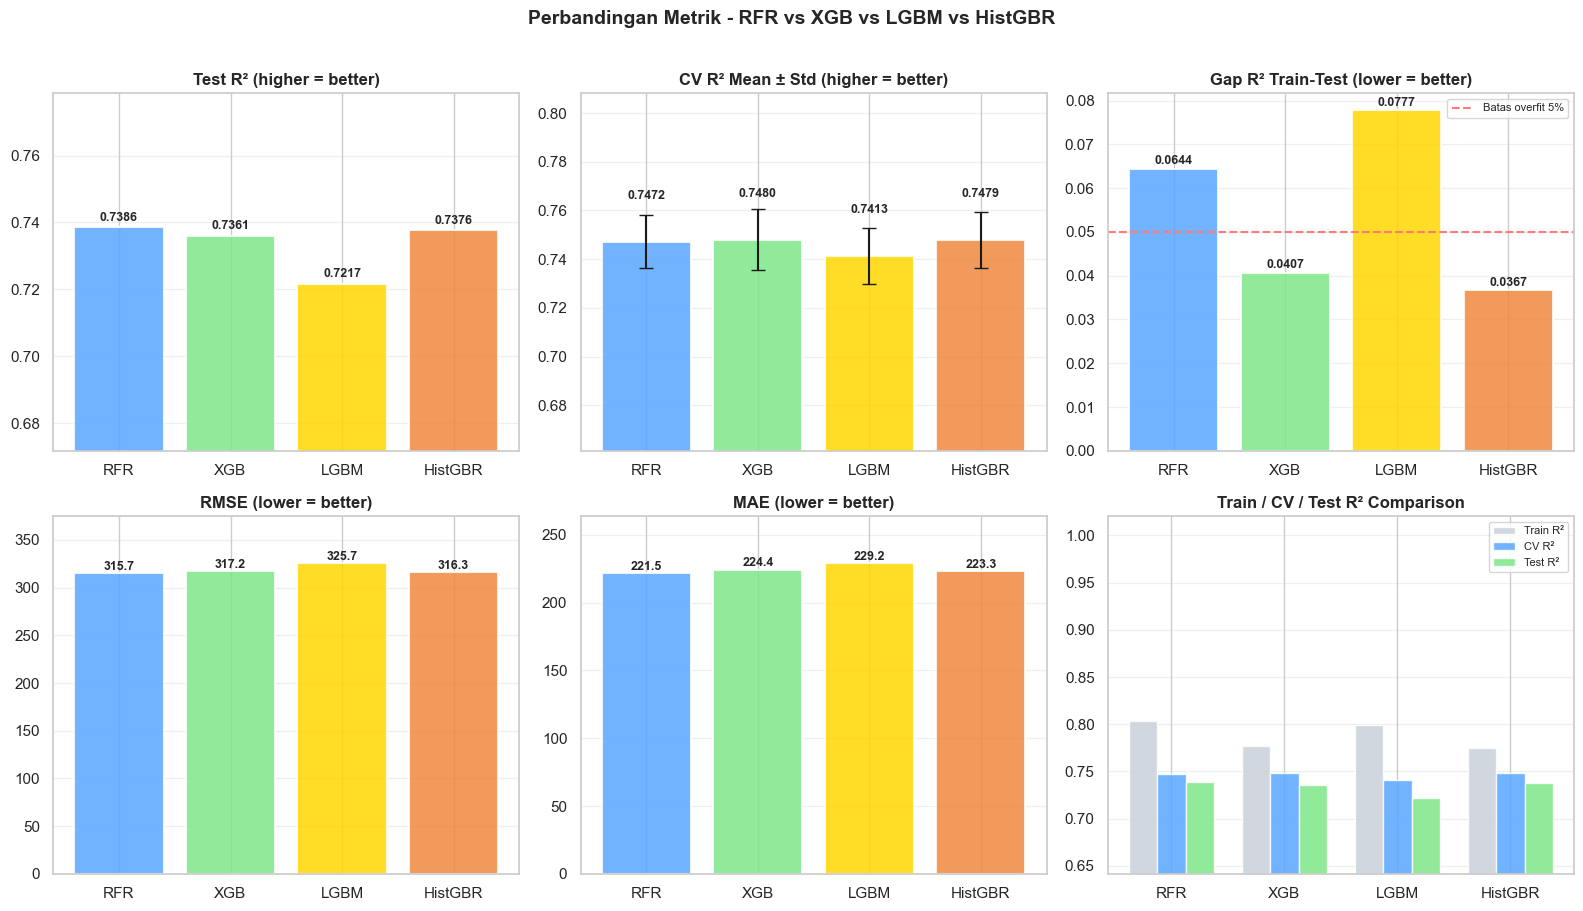

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

model_names = list(all_models.keys())
colors = [MODEL_COLORS[n] for n in model_names]

# 1) Test R2
ax = axes[0, 0]
vals = [results[n]['test_r2'] for n in model_names]
bars = ax.bar(model_names, vals, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_title('Test R² (higher = better)', fontweight='bold')
ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.04))
ax.grid(True, axis='y', alpha=0.3)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
            f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# 2) CV R2 with error bars
ax = axes[0, 1]
cv_means = [results[n]['cv_mean'] for n in model_names]
cv_stds  = [results[n]['cv_std']  for n in model_names]
bars = ax.bar(model_names, cv_means, color=colors, alpha=0.85,
              yerr=cv_stds, capsize=5, edgecolor='white', linewidth=1.5)
ax.set_title('CV R² Mean ± Std (higher = better)', fontweight='bold')
ax.set_ylim(max(0, min(cv_means) - 0.08), min(1.0, max(cv_means) + 0.06))
ax.grid(True, axis='y', alpha=0.3)
for b, v in zip(bars, cv_means):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(cv_stds) + 0.005,
            f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# 3) Gap (Train - Test)
ax = axes[0, 2]
gaps = [results[n]['gap'] for n in model_names]
bars = ax.bar(model_names, gaps, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axhline(0.05, color='#FF7B7B', lw=1.5, linestyle='--', label='Batas overfit 5%')
ax.axhline(0.00, color='gray', lw=1)
ax.set_title('Gap R² Train-Test (lower = better)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
for b, v in zip(bars, gaps):
    ax.text(b.get_x() + b.get_width()/2, v + 0.001,
            f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# 4) RMSE
ax = axes[1, 0]
rmses = [results[n]['rmse'] for n in model_names]
bars = ax.bar(model_names, rmses, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_title('RMSE (lower = better)', fontweight='bold')
ax.set_ylim(0, max(rmses) * 1.15)
ax.grid(True, axis='y', alpha=0.3)
for b, v in zip(bars, rmses):
    ax.text(b.get_x() + b.get_width()/2, v + max(rmses)*0.01,
            f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# 5) MAE
ax = axes[1, 1]
maes = [results[n]['mae'] for n in model_names]
bars = ax.bar(model_names, maes, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_title('MAE (lower = better)', fontweight='bold')
ax.set_ylim(0, max(maes) * 1.15)
ax.grid(True, axis='y', alpha=0.3)
for b, v in zip(bars, maes):
    ax.text(b.get_x() + b.get_width()/2, v + max(maes)*0.01,
            f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# 6) Radar-like: Train R2 vs Test R2 vs CV R2
ax = axes[1, 2]
x = np.arange(len(model_names))
w = 0.25
train_r2s = [results[n]['train_r2'] for n in model_names]
ax.bar(x - w, train_r2s, w, label='Train R²', color='#C9D1D9', alpha=0.85, edgecolor='white')
ax.bar(x,     cv_means,  w, label='CV R²',    color='#58A6FF', alpha=0.85, edgecolor='white')
ax.bar(x + w, vals,      w, label='Test R²',  color='#7EE787', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_title('Train / CV / Test R² Comparison', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(max(0, min(train_r2s + cv_means + vals) - 0.08), 1.02)
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Perbandingan Metrik - RFR vs XGB vs LGBM vs HistGBR',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

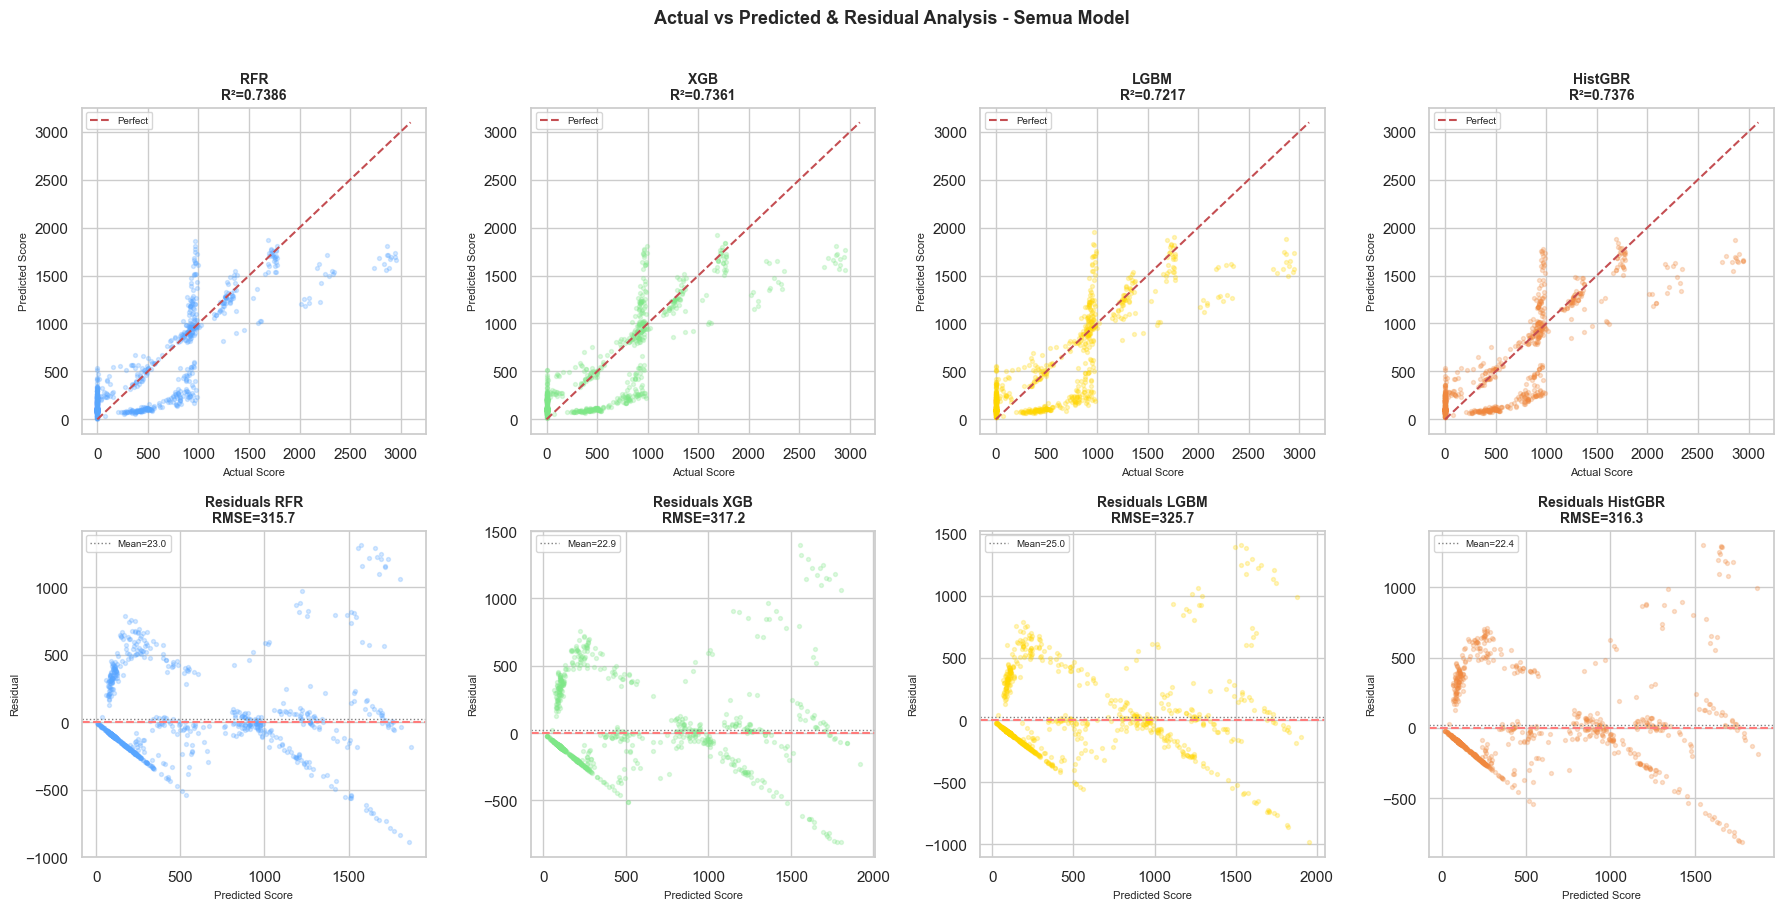

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, (name, model) in enumerate(all_models.items()):
    color = MODEL_COLORS[name]
    y_te  = results[name]['y_pred_te']
    resid = y_test - y_te

    # Actual vs Predicted
    ax = axes[0, col]
    ax.scatter(y_test, y_te, alpha=0.25, s=8, color=color)
    lim = max(y_test.max(), y_te.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect')
    ax.set_xlabel('Actual Score', fontsize=8)
    ax.set_ylabel('Predicted Score', fontsize=8)
    r2_val = results[name]['test_r2']
    ax.set_title(f'{name}\nR²={r2_val:.4f}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)

    # Residuals
    ax2 = axes[1, col]
    ax2.scatter(y_te, resid, alpha=0.25, s=8, color=color)
    ax2.axhline(0, color='#FF7B7B', lw=1.5, linestyle='--')
    ax2.axhline(resid.mean(), color='gray', lw=1, linestyle=':',
                label=f'Mean={resid.mean():.1f}')
    ax2.set_xlabel('Predicted Score', fontsize=8)
    ax2.set_ylabel('Residual', fontsize=8)
    ax2.set_title(f'Residuals {name}\nRMSE={results[name]["rmse"]:.1f}',
                 fontweight='bold', fontsize=10)
    ax2.legend(fontsize=7)

plt.suptitle('Actual vs Predicted & Residual Analysis - Semua Model',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. ***Learning Curves***

*Learning curve* menunjukkan apakah model:
- **Underfit** - train dan val sama-sama rendah (kurva tidak naik)
- **Overfit** - train jauh lebih tinggi dari val (gap besar)
- **Baik** - train dan val konvergen ke nilai tinggi

Gap (Train - Val) < 0.05 pada seluruh rentang *training size* = model generalisasi baik.

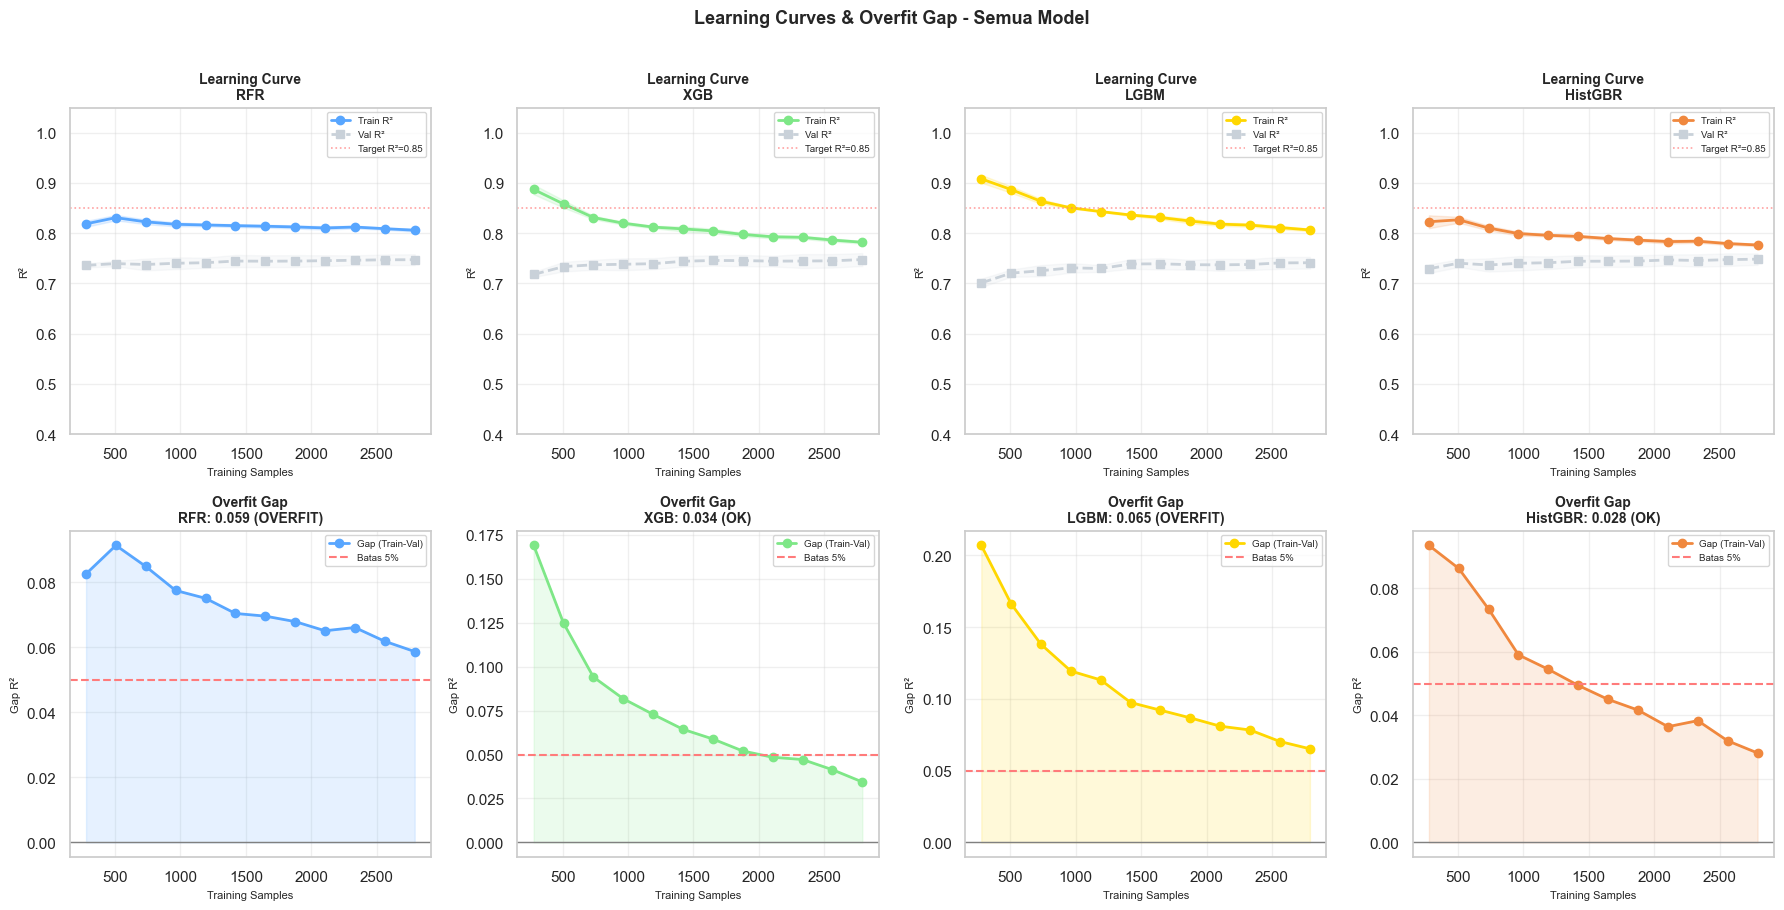

Diagnosis Gap (pada training size penuh):
  RFR   : Gap=0.0557 -> OVERFIT (>= 5%)
  XGB   : Gap=0.0287 -> OK  (< 5%)
  LGBM  : Gap=0.0581 -> OVERFIT (>= 5%)
  HistGBR: Gap=0.0264 -> OK  (< 5%)


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
lc_kf = KFold(5, shuffle=True, random_state=RANDOM_SEED)
train_sizes_pct = np.linspace(0.10, 1.0, 12)

for col, (name, model) in enumerate(all_models.items()):
    color = MODEL_COLORS[name]
    tr_sz, tr_sc, val_sc = learning_curve(
        model, X_train, y_train,
        cv=lc_kf,
        train_sizes=train_sizes_pct,
        scoring='r2',
        n_jobs=-1,
    )
    tr_m, tr_s = tr_sc.mean(axis=1), tr_sc.std(axis=1)
    va_m, va_s = val_sc.mean(axis=1), val_sc.std(axis=1)
    gap_arr    = tr_m - va_m

    # Learning curve
    ax = axes[0, col]
    ax.plot(tr_sz, tr_m, 'o-', color=color, lw=2, label='Train R²')
    ax.fill_between(tr_sz, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color=color)
    ax.plot(tr_sz, va_m, 's--', color='#C9D1D9', lw=2, label='Val R²')
    ax.fill_between(tr_sz, va_m - va_s, va_m + va_s, alpha=0.12, color='#C9D1D9')
    ax.axhline(0.85, color='#FF7B7B', lw=1.2, linestyle=':', alpha=0.7, label='Target R²=0.85')
    ax.set_xlabel('Training Samples', fontsize=8)
    ax.set_ylabel('R²', fontsize=8)
    ax.set_title(f'Learning Curve\n{name}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylim(0.4, 1.05)
    ax.grid(True, alpha=0.3)

    # Gap curve
    ax2 = axes[1, col]
    ax2.plot(tr_sz, gap_arr, 'o-', color=color, lw=2, label='Gap (Train-Val)')
    ax2.axhline(0.05, color='#FF7B7B', lw=1.5, linestyle='--', label='Batas 5%')
    ax2.axhline(0.00, color='gray', lw=1)
    ax2.fill_between(tr_sz, 0, gap_arr, alpha=0.15, color=color)
    ax2.set_xlabel('Training Samples', fontsize=8)
    ax2.set_ylabel('Gap R²', fontsize=8)
    final_gap = gap_arr[-1]
    diagnosis = 'OK' if final_gap < 0.05 else 'OVERFIT'
    ax2.set_title(f'Overfit Gap\n{name}: {final_gap:.3f} ({diagnosis})',
                 fontweight='bold', fontsize=10)
    ax2.legend(fontsize=7)
    ax2.grid(True, alpha=0.3)

plt.suptitle('Learning Curves & Overfit Gap - Semua Model',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Diagnosis Gap (pada training size penuh):')
for name, model in all_models.items():
    cv_sc = cross_val_score(model, X_train, y_train, cv=lc_kf, scoring='r2')
    tr_r2 = results[name]['train_r2']
    gap_f = tr_r2 - cv_sc.mean()
    status = 'OK  (< 5%)' if gap_f < 0.05 else 'OVERFIT (>= 5%)'
    print(f'  {name:<6}: Gap={gap_f:.4f} -> {status}')

## 7. ***Robustness Test - Multi-Seed Validation***

Menguji stabilitas setiap model dengan **10 random seed** berbeda untuk KFold. Model yang robust memiliki **std CV < 0.02** di semua seed. Model yang tidak stabil (std tinggi) berisiko memberikan prediksi yang bervariasi bergantung pada distribusi data, yang berbahaya untuk aplikasi nyata.

  Seed         RFR         XGB        LGBM     HistGBR
--------------------------------------------------------
     0      0.7465      0.7458      0.7426      0.7454
     7      0.7446      0.7422      0.7369      0.7453
    13      0.7470      0.7470      0.7419      0.7483
    21      0.7484      0.7483      0.7441      0.7467
    42      0.7472      0.7469      0.7410      0.7462
    99      0.7467      0.7450      0.7408      0.7482
   123      0.7476      0.7475      0.7415      0.7475
   256      0.7444      0.7440      0.7373      0.7444
   512      0.7463      0.7463      0.7394      0.7464
  1337      0.7469      0.7454      0.7417      0.7458
Metric           RFR         XGB        LGBM     HistGBR
--------------------------------------------------------
Mean        0.7466      0.7459      0.7407      0.7464
Std         0.0012      0.0017      0.0022      0.0012  (lower=better)

Diagnosis Robustness:
  RFR   : std=0.0012 -> Sangat Stabil (std < 0.01)
  XGB   : std=0.0017 -> 

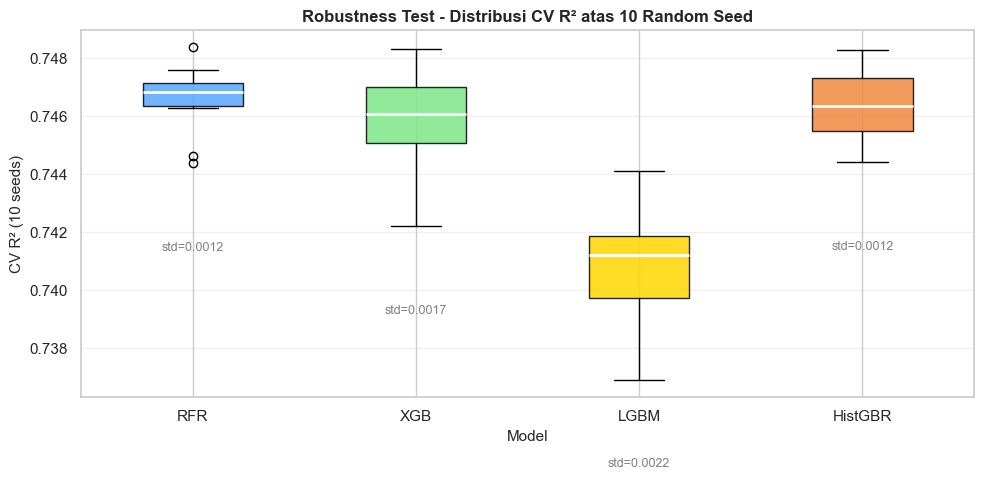

In [14]:
TEST_SEEDS = [0, 7, 13, 21, 42, 99, 123, 256, 512, 1337]
rob_results = {name: [] for name in all_models}

print(f"{'Seed':>6}  {'RFR':>10}  {'XGB':>10}  {'LGBM':>10}  {'HistGBR':>10}")
print('-' * 56)
for seed in TEST_SEEDS:
    kf_s = KFold(n_splits=5, shuffle=True, random_state=seed)
    row = f'{seed:>6}'
    for name, model in all_models.items():
        sc = cross_val_score(model, X, y, cv=kf_s, scoring='r2')
        rob_results[name].append(sc.mean())
        row += f'  {sc.mean():>10.4f}'
    print(row)

print('=' * 56)
print(f"{'Metric':<8}  {'RFR':>10}  {'XGB':>10}  {'LGBM':>10}  {'HistGBR':>10}")
print('-' * 56)

rob_means = {n: np.mean(rob_results[n]) for n in all_models}
rob_stds  = {n: np.std(rob_results[n])  for n in all_models}

row_m = 'Mean  '
row_s = 'Std   '
for name in all_models:
    row_m += f'  {rob_means[name]:>10.4f}'
    row_s += f'  {rob_stds[name]:>10.4f}'
print(row_m)
print(row_s + '  (lower=better)')
print()
print('Diagnosis Robustness:')
for name in all_models:
    std = rob_stds[name]
    if std < 0.01:
        status = 'Sangat Stabil (std < 0.01)'
    elif std < 0.02:
        status = 'Stabil (std < 0.02)'
    else:
        status = 'Kurang Stabil (std >= 0.02)'
    print(f'  {name:<6}: std={std:.4f} -> {status}')

# Boxplot robustness
fig, ax = plt.subplots(figsize=(10, 5))
data_box = [rob_results[n] for n in all_models]
bp = ax.boxplot(data_box, labels=list(all_models.keys()), patch_artist=True,
                medianprops={'color': 'white', 'linewidth': 2})
for patch, name in zip(bp['boxes'], all_models):
    patch.set_facecolor(MODEL_COLORS[name])
    patch.set_alpha(0.85)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('CV R² (10 seeds)', fontsize=11)
ax.set_title('Robustness Test - Distribusi CV R² atas 10 Random Seed',
             fontweight='bold', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
for i, name in enumerate(all_models):
    ax.text(i + 1, min(rob_results[name]) - 0.003,
            f'std={rob_stds[name]:.4f}', ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

## 8. ***Feature Importance***

Setiap model memiliki cara mengukur kepentingan fitur:
- **RFR** - *Mean Decrease Impurity* (MDI) *built-in*
- **XGB / LGBM / HistGBR** - *Gain-based importance built-in*
- **Permutation Importance** - model-*agnostic*, lebih *reliable* untuk perbandingan lintas model

Konsistensi ranking fitur di semua model menunjukkan bahwa sinyal fitur *genuine* (bukan *noise*).

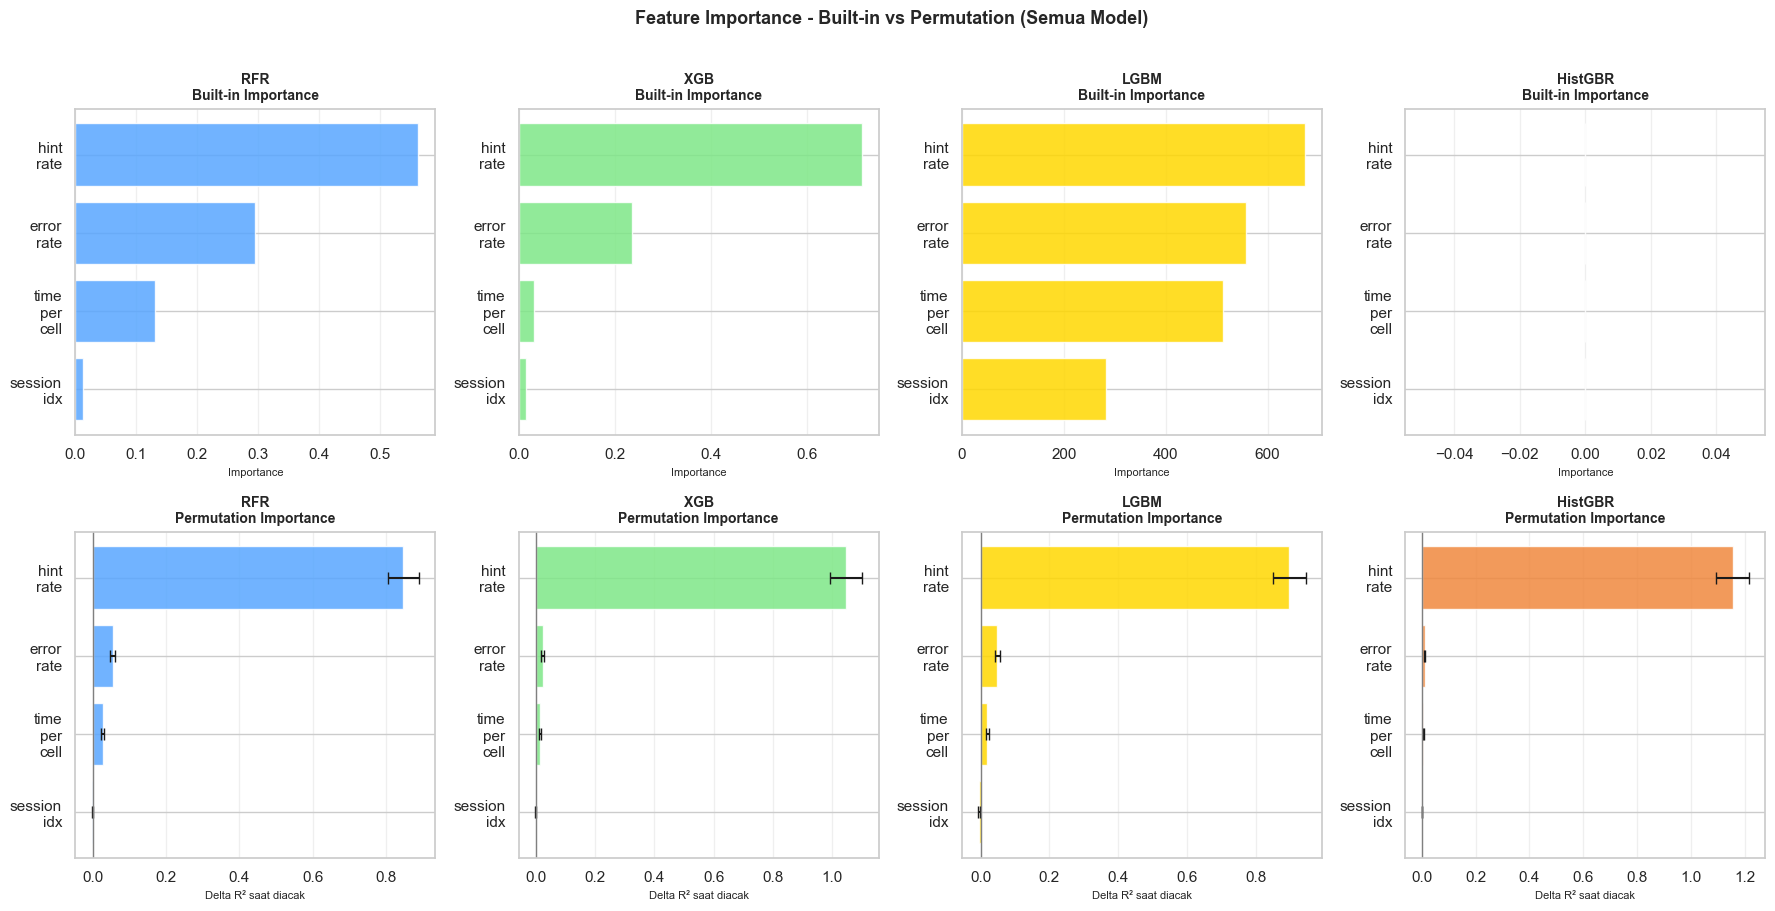

Ranking Permutation Importance (1=paling penting):
Fitur                   RFR    XGB   LGBM HistGBR
--------------------------------------------
session_idx               4      4      4      4
time_per_cell             3      3      3      3
error_rate                2      2      2      2
hint_rate                 1      1      1      1


In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, (name, model) in enumerate(all_models.items()):
    color = MODEL_COLORS[name]

    # Built-in Feature Importance
    ax = axes[0, col]
    if hasattr(model, 'feature_importances_'):
        fi = model.feature_importances_
    else:
        fi = np.zeros(len(FEATURE_NAMES))
    fi_idx = np.argsort(fi)
    feat_labels = [FEATURE_NAMES[i].replace('_', '\n') for i in fi_idx]
    ax.barh(feat_labels, fi[fi_idx], color=color, alpha=0.85)
    ax.set_xlabel('Importance', fontsize=8)
    ax.set_title(f'{name}\nBuilt-in Importance', fontweight='bold', fontsize=10)
    ax.grid(True, axis='x', alpha=0.3)

    # Permutation Importance
    ax2 = axes[1, col]
    perm = permutation_importance(
        model, X_test, y_test,
        n_repeats=20,
        random_state=RANDOM_SEED,
        scoring='r2',
    )
    pi_idx = np.argsort(perm.importances_mean)
    pi_labels = [FEATURE_NAMES[i].replace('_', '\n') for i in pi_idx]
    ax2.barh(pi_labels, perm.importances_mean[pi_idx],
             xerr=perm.importances_std[pi_idx],
             color=color, alpha=0.85, capsize=4)
    ax2.axvline(0, color='gray', lw=1)
    ax2.set_xlabel('Delta R² saat diacak', fontsize=8)
    ax2.set_title(f'{name}\nPermutation Importance', fontweight='bold', fontsize=10)
    ax2.grid(True, axis='x', alpha=0.3)

plt.suptitle('Feature Importance - Built-in vs Permutation (Semua Model)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Ringkasan ranking konsistensi
print('Ranking Permutation Importance (1=paling penting):')
print(f"{'Fitur':<20} {'RFR':>6} {'XGB':>6} {'LGBM':>6} {'HistGBR':>6}")
print('-' * 44)
for feat in FEATURE_NAMES:
    row = f'{feat:<20}'
    for name, model in all_models.items():
        perm = permutation_importance(
            model, X_test, y_test, n_repeats=10,
            random_state=RANDOM_SEED, scoring='r2'
        )
        fi_idx_full = np.argsort(perm.importances_mean)[::-1]
        rank = list(fi_idx_full).index(
            FEATURE_NAMES.index(feat)
        ) + 1
        row += f' {rank:>6}'
    print(row)

## 9. ***Summary***

Evaluasi final menggunakan **5 kriteria utama** (masing-masing diberi bobot):

| Kriteria | Bobot | Keterangan |
|---|---|---|
| Test R² | 30% | Akurasi pada data unseen |
| CV R² Mean | 25% | Generalisasi via cross-validation |
| Gap R² | 20% | Tidak overfit (lower=better) |
| Robustness std | 15% | Stabilitas antar seed (lower=better) |
| RMSE | 10% | Error dalam satuan skor |

> Model terbaik untuk deployment adalah yang **seimbang** di semua kriteria, bukan hanya yang memiliki Test R² tertinggi.

=== Tabel Perbandingan Final ===
Metrik                    RFR      XGB     LGBM  HistGBR  Notes
------------------------------------------------------------------------
Test R2                0.7386   0.7361   0.7217   0.7376  higher=better
CV R2 mean             0.7472   0.7480   0.7413   0.7479  higher=better
CV R2 std              0.0108   0.0125   0.0114   0.0115  lower=better
Gap R2                 0.0644   0.0407   0.0777   0.0367  lower=better (<0.05)
RMSE                    315.7    317.2    325.7    316.3  lower=better
MAE                     221.5    224.4    229.2    223.3  lower=better
Robust std             0.0012   0.0017   0.0022   0.0012  lower=better (<0.02)
Pred<0 after clip           0        0        0        0  harus 0
Final Score            0.8353   0.8400   0.0000   0.9677  (weighted composite)

Model Terbaik (Composite Score): HistGBR
  Test R²        : 0.7376
  CV R²          : 0.7479 +/- 0.0115
  Gap R²         : 0.0367
  RMSE           : 316.3
  Prediksi < 0

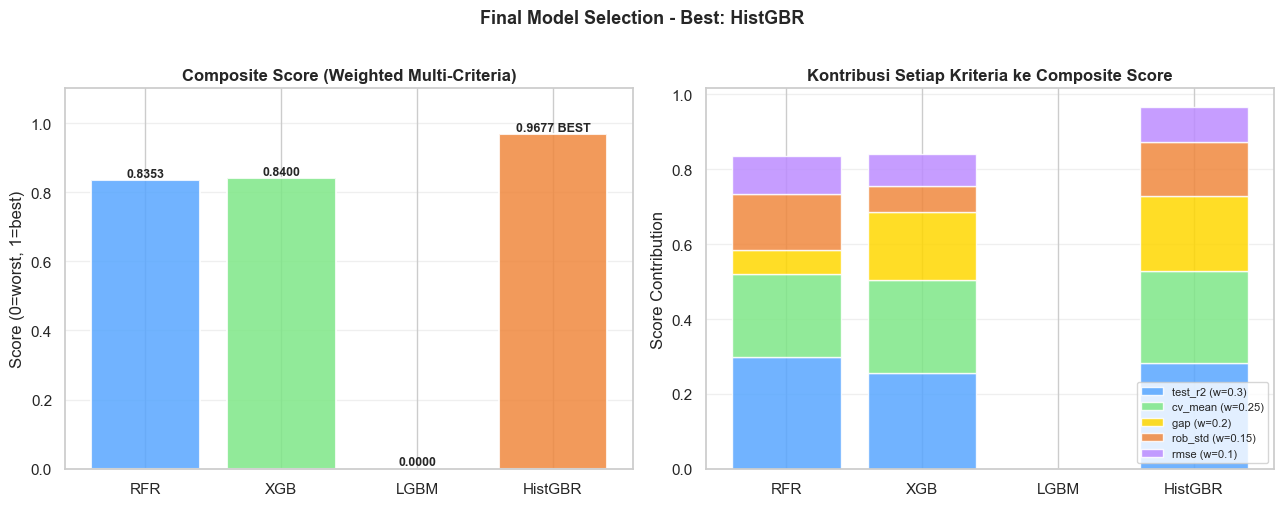

In [16]:
# Normalisasi dan scoring multi-kriteria
def minmax_norm(vals, higher_is_better=True):
    v = np.array(vals, dtype=float)
    if v.max() == v.min():
        return np.ones_like(v)
    norm = (v - v.min()) / (v.max() - v.min())
    return norm if higher_is_better else 1 - norm

model_names_list = list(all_models.keys())

test_r2_vals  = [results[n]['test_r2']  for n in model_names_list]
cv_mean_vals  = [results[n]['cv_mean']  for n in model_names_list]
gap_vals      = [results[n]['gap']      for n in model_names_list]
rmse_vals     = [results[n]['rmse']     for n in model_names_list]
rob_std_vals  = [rob_stds[n]            for n in model_names_list]

weights = {'test_r2': 0.30, 'cv_mean': 0.25, 'gap': 0.20,
           'rob_std': 0.15, 'rmse': 0.10}

scores_norm = {
    'test_r2': minmax_norm(test_r2_vals, higher_is_better=True),
    'cv_mean': minmax_norm(cv_mean_vals, higher_is_better=True),
    'gap':     minmax_norm(gap_vals,     higher_is_better=False),
    'rob_std': minmax_norm(rob_std_vals, higher_is_better=False),
    'rmse':    minmax_norm(rmse_vals,    higher_is_better=False),
}

final_scores = np.zeros(len(model_names_list))
for metric, w in weights.items():
    final_scores += w * scores_norm[metric]

print('=== Tabel Perbandingan Final ===')
print(f"{'Metrik':<20} {'RFR':>8} {'XGB':>8} {'LGBM':>8} {'HistGBR':>8}  Notes")
print('-' * 72)
rows_final = [
    ('Test R2',         test_r2_vals,  '{:.4f}', 'higher=better'),
    ('CV R2 mean',      cv_mean_vals,  '{:.4f}', 'higher=better'),
    ('CV R2 std',       [results[n]['cv_std'] for n in model_names_list], '{:.4f}', 'lower=better'),
    ('Gap R2',          gap_vals,      '{:.4f}', 'lower=better (<0.05)'),
    ('RMSE',            rmse_vals,     '{:.1f}',  'lower=better'),
    ('MAE',             [results[n]['mae'] for n in model_names_list], '{:.1f}', 'lower=better'),
    ('Robust std',      rob_std_vals,  '{:.4f}', 'lower=better (<0.02)'),
    ('Pred<0 after clip', [0]*4,       '{:.0f}',  'harus 0'),
]
for label, vals, fmt, note in rows_final:
    row = f'{label:<20}'
    for v in vals:
        row += f' {fmt.format(v):>8}'
    print(row + f'  {note}')
print('=' * 72)
row_fs = f"{'Final Score':<20}"
for s in final_scores:
    row_fs += f' {s:>8.4f}'
print(row_fs + '  (weighted composite)')
print()

best_idx  = np.argmax(final_scores)
best_name = model_names_list[best_idx]
print(f'Model Terbaik (Composite Score): {best_name}')
print(f'  Test R²        : {results[best_name]["test_r2"]:.4f}')
print(f'  CV R²          : {results[best_name]["cv_mean"]:.4f} +/- {results[best_name]["cv_std"]:.4f}')
print(f'  Gap R²         : {results[best_name]["gap"]:.4f}')
print(f'  RMSE           : {results[best_name]["rmse"]:.1f}')
print(f'  Prediksi < 0   : 0 (di-clip oleh np.maximum(0, pred))')

# Radar / spider chart alternatif - bar chart composite score
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bar_colors = [MODEL_COLORS[n] for n in model_names_list]
bars = ax.bar(model_names_list, final_scores, color=bar_colors, alpha=0.85,
              edgecolor='white', linewidth=1.5)
ax.set_title('Composite Score (Weighted Multi-Criteria)', fontweight='bold')
ax.set_ylabel('Score (0=worst, 1=best)')
ax.set_ylim(0, 1.1)
ax.grid(True, axis='y', alpha=0.3)
for b, v, name in zip(bars, final_scores, model_names_list):
    label = f'{v:.4f}'
    if name == best_name:
        label += ' BEST'
    ax.text(b.get_x() + b.get_width()/2, v + 0.01,
            label, ha='center', fontsize=9, fontweight='bold')

# Stacked contribution per criteria
ax2 = axes[1]
bottom = np.zeros(len(model_names_list))
crit_colors = ['#58A6FF', '#7EE787', '#FFD700', '#F0883E', '#BC8CFF']
crit_labels = list(weights.keys())
for metric, w, col in zip(crit_labels, weights.values(), crit_colors):
    contrib = w * scores_norm[metric]
    ax2.bar(model_names_list, contrib, bottom=bottom,
            color=col, alpha=0.85, label=f'{metric} (w={w})', edgecolor='white')
    bottom += contrib
ax2.set_title('Kontribusi Setiap Kriteria ke Composite Score', fontweight='bold')
ax2.set_ylabel('Score Contribution')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle(f'Final Model Selection - Best: {best_name}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. ***Save & Verify Model***

In [17]:
folder = Path('Files')
folder.mkdir(parents=True, exist_ok=True)

# Hitung RMSE untuk melengkapi metadata
final_rmse = float(np.sqrt(mean_squared_error(
                       y_test, np.maximum(0, best_HistGBR.predict(X_test)))))

# Siapkan payload dengan mengambil variabel metrik sebelumnya
payload = {
    'model': best_HistGBR,
    'r2':    HistGBR_test_r2,
    'meta': {
        'model_type':    type(best_HistGBR).__name__,
        'model_key':     'HistGBR',
        'rmse':          final_rmse,
        'cv_r2_mean':    float(HistGBR_search.best_score_),
        'test_r2':       float(HistGBR_test_r2),
        'gap_r2':        float(HistGBR_train_r2 - HistGBR_test_r2),
        'feature_names': FEATURE_NAMES,
        'n_train':       len(X_train),
        'needs_scaler':  False,
        'clip_negative': True, 
    }
}

path_folder = folder / 'Score_Prediction.pkl'

# Simpan ke file pickle
with open(path_folder, 'wb') as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

# Hitung ukuran file lalu cetak informasi
size_kb = os.path.getsize(path_folder) / 1024
print(f"Model tersimpan: {path_folder} ({size_kb:.1f} KB)")
print(f"Metrik HistGBR    : R2={HistGBR_test_r2:.4f} RMSE={final_rmse:.1f} CV={HistGBR_search.best_score_:.4f}")

Model tersimpan: Files\Score_Prediction.pkl (129.1 KB)
Metrik HistGBR    : R2=0.7376 RMSE=316.3 CV=0.7479


In [18]:
# Verifikasi
test_cases = [
    ([3,  12.0*0.95, 0.18*0.95, 0.10*0.95], 'Pemain baru          (n=3)'),
    ([8,   6.0*0.95, 0.08*0.95, 0.04*0.95], 'Pemain menengah      (n=8)'),
    ([20,  3.0*0.95, 0.02*0.95, 0.01*0.95], 'Pemain berpengalaman (n=20)'),
    ([50,  2.0*0.95, 0.01*0.95, 0.00*0.95], 'Pemain veteran       (n=50)'),
    ([2,  25.0*0.95, 0.45*0.95, 0.40*0.95], 'Pemain kesulitan     (n=2)'),
]

print('Verifikasi predict_next_score() untuk HistGBR')
print(f"{'Skenario':<30} {'HistGBR':>7}")
print('=' * 40)

any_negative = False
path_folder = folder / 'Score_Prediction.pkl'

# Membuka file dari media penyimpanan untuk simulasi
with open(path_folder, 'rb') as f:
    loaded = pickle.load(f)

for feats, desc in test_cases:
    # Meminta model melakukan prediksi
    raw  = float(loaded['model'].predict([feats])[0])
    
    # Memastikan tidak ada skor negatif
    safe = max(0, int(raw))
    if raw < 0:
        any_negative = True
        
    print(f'{desc:<30} {safe:>7}')

Verifikasi predict_next_score() untuk HistGBR
Skenario                       HistGBR
Pemain baru          (n=3)         438
Pemain menengah      (n=8)        1237
Pemain berpengalaman (n=20)       1834
Pemain veteran       (n=50)       1517
Pemain kesulitan     (n=2)          41
